<a href="https://colab.research.google.com/github/crahulnaidu/recursive-self-improving-ai/blob/main/month_1/ai_month_1_day_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold,train_test_split
from sklearn.linear_model import LinearRegression


In [5]:
X=np.linspace(0,1,100).reshape(-1,1)
Y=np.sin(2*np.pi*X)+0.4*np.random.randn(100,1)

poly=PolynomialFeatures(degree=10)
X_poly=poly.fit_transform(X)

kf=KFold(n_splits=5,shuffle=True)

error=[]

for train_ind,val_ind in kf.split(X_poly):
  X_train_poly,X_val_poly=X_poly[train_ind],X_poly[val_ind]
  y_train_poly,y_val_poly=Y[train_ind],Y[val_ind]

  model=LinearRegression()
  model.fit(X_train_poly,y_train_poly)

  error.append(np.sum((model.predict(X_val_poly)-y_val_poly)**2))

print("validation error",np.sum(error))




validation error 22.182297167585332


In [7]:
#Model selection using k fold cross validation

degree=[1,3,5,10,15]

k_fold_error=[]

for deg in degree:
  cv_error=[]
  poly=PolynomialFeatures(deg)
  X_poly=poly.fit_transform(X)

  kf=KFold(n_splits=5,shuffle=True)
  for train_ind,val_ind in kf.split(X_poly):
    X_train_poly,X_val_poly=X_poly[train_ind],X_poly[val_ind]
    y_train,y_val=Y[train_ind],Y[val_ind]

    model=LinearRegression()
    model.fit(X_train_poly,y_train)

    cv_error.append(np.sum((model.predict(X_val_poly)-y_val)**2))

  k_fold_error.append(np.sum(cv_error))


print("best degree with the leat k_fold error",degree[np.argmin(k_fold_error)])

best degree with the leat k_fold error 5


/tmp/ipykernel_727/4024947252.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


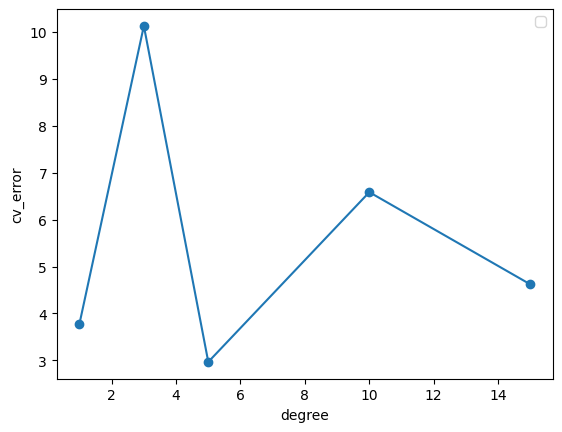

In [9]:
plt.plot(degree,cv_error,marker='o')
plt.xlabel("degree")
plt.ylabel("cv_error")
plt.legend()
plt.show()

In [11]:
#comparing validation and cross validation error for degree 5


poly=PolynomialFeatures(degree=5)
X_poly=poly.fit_transform(X)


X_train,X_temp,y_train,y_temp=train_test_split(X_poly,Y,test_size=0.4)

X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.5)

model=LinearRegression()
model.fit(X_train,y_train)


val_error=np.sum((model.predict(X_val)-y_val)**2)

print("cross validation error",cv_error[2])

print("validation error",val_error)




cross validation error 2.968474672661616
validation error 4.728658134685072
